# AgentShield — Phase 7 eval

Score a **live end-to-end run** of AgentShield against the synthetic generator's ground truth, per family.

The generator (`services/generator`) mints a replayable *Scenario*: for every debit it records the verdict the debit is *meant* to receive (`expected_decision` / `expected_code`, from `families.LEGEND`) and the settled label it is *meant* to teach the labeler. The live driver (`services/driver`) replays that Scenario against the **real** split-process system — real gRPC `Evaluate`, real Redis feature store, real Redpanda bus, the real Go labeler — and the oracle joins ground truth to what the system actually did, writing `results.json`.

This notebook reads that `results.json` and measures fidelity: per-family accuracy, the decision/code confusion matrices, the settled-label breakdown, and an expected-loss framing (how much at-risk value the system gated vs let through).

> **Invariant under test:** only predicates **P1–P6** may BLOCK; the three ML engines only ever *raise risk* / trigger STEP_UP; the decision is expected-loss (calibrated p × rupees) vs interruption cost. A faithful two-plane replay should reproduce every family's intended verdict.

In [1]:
import os, sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# Make the eval core importable whether the kernel starts in services/eval or the notebook dir.
for _cand in (Path.cwd(), *Path.cwd().parents):
    if (_cand / "agentshield_eval").is_dir():
        sys.path.insert(0, str(_cand)); break
import agentshield_eval as ev


def find_results():
    env = os.environ.get("AGENTSHIELD_RESULTS")
    if env:
        return Path(env)
    for base in (Path.cwd(), *Path.cwd().parents):
        for name in ("sample_results.json", "results.json"):
            if (base / name).exists():
                return base / name
    raise FileNotFoundError("no results.json found - set AGENTSHIELD_RESULTS or drop one in services/eval/")

RESULTS_PATH = find_results()
results = ev.load_results(RESULTS_PATH)
meta = results.get("meta", {})
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3, "font.size": 10})
print(f"loaded {RESULTS_PATH}  (seed={meta.get('seed')}, generator {meta.get('generator_version')})")

loaded /home/sagar/Desktop/Risk_Scorer_System/AgentShield/services/eval/sample_results.json  (seed=7, generator 0.1.0)


## 1 · Headline

In [2]:
h = ev.headline(results)
totals = meta.get("totals", {})
print(f"debits evaluated : {h['evaluated']} / {h['debits']}")
print(f"decision accuracy: {h['decision_accuracy']:.1%}")
print(f"code accuracy    : {h['code_accuracy']:.1%}")
print(f"barrier warnings : {h['warnings']}")
if "run_seconds" in h:
    print(f"wall-clock       : {h['run_seconds']}s")
print(f"scenario         : {totals}")

debits evaluated : 78 / 78
decision accuracy: 100.0%
code accuracy    : 100.0%
barrier warnings : 0
wall-clock       : 31.61s
scenario         : {'tokens': 50, 'overlays': 2, 'envelopes': 50, 'debits': 78, 'cancellations': 2, 'misuse_debits': 49}


## 2 · Per-family accuracy

Each family should sit at 1.0 on both bars. `[misuse]` families are engineered to trip a specific mechanism (a predicate BLOCK, a scope STEP_UP, a learned-risk STEP_UP); `[legit]` traffic should pass clean.

,family,count,evaluated,decision_accuracy,code_accuracy,is_misuse
0,intent_drift,4,4,1.0,1.0,True
1,legit,29,29,1.0,1.0,False
2,mule_fan_in,6,6,1.0,1.0,True
3,replay,3,3,1.0,1.0,True
4,scope_overrun,4,4,1.0,1.0,True
5,shared_device_ring,10,10,1.0,1.0,True
6,stale_revoked_token,4,4,1.0,1.0,True
7,synchronised_fleet,6,6,1.0,1.0,True
8,velocity_bustout,12,12,1.0,1.0,True


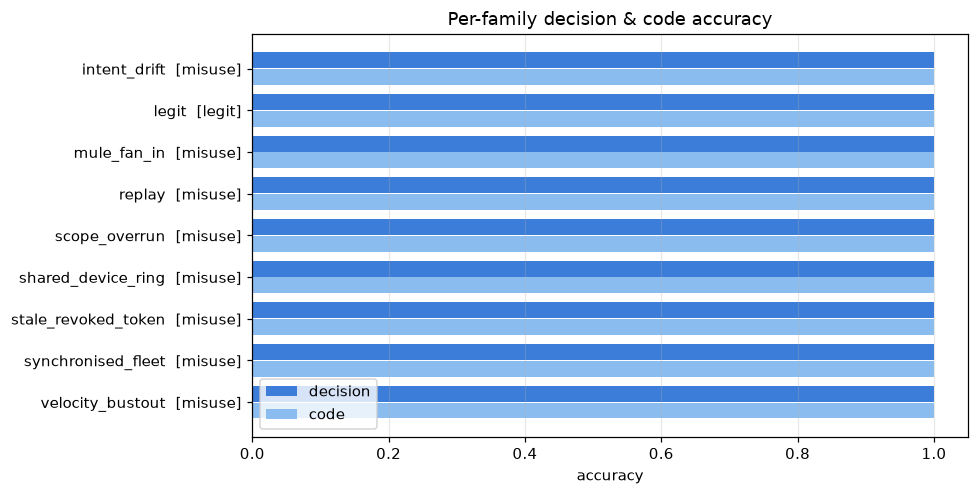

In [3]:
fam = pd.DataFrame(ev.family_table(results)).sort_values("family").reset_index(drop=True)
display(fam)

fig, ax = plt.subplots(figsize=(9, 4.6))
y = np.arange(len(fam))
ax.barh(y - 0.2, fam["decision_accuracy"], height=0.38, label="decision", color="#3b7dd8")
ax.barh(y + 0.2, fam["code_accuracy"], height=0.38, label="code", color="#8bbcf0")
ax.set_yticks(y)
ax.set_yticklabels([f"{f}  [{'misuse' if m else 'legit'}]" for f, m in zip(fam["family"], fam["is_misuse"])])
ax.set_xlim(0, 1.05); ax.set_xlabel("accuracy"); ax.invert_yaxis()
ax.set_title("Per-family decision & code accuracy")
ax.legend(loc="lower left"); ax.grid(axis="y", alpha=0)
fig.tight_layout(); plt.show()

## 3 · Confusion matrices

Rows are the **expected** (ground-truth) class, columns the **actual** (live) class. A purely diagonal grid means the system reproduced ground truth exactly — every off-diagonal cell is a mismatch.

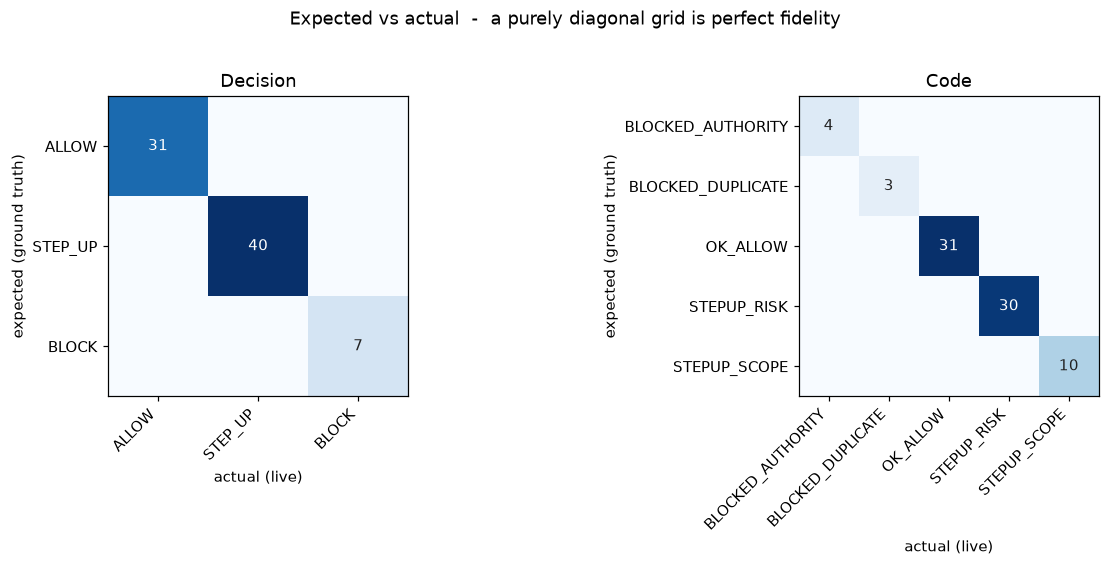

decision off-diagonal (mismatches): 0
code off-diagonal (mismatches)    : 0


In [4]:
def heatmap(ax, labels, m, title):
    ax.imshow(m, cmap="Blues")
    ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels)
    ax.set_xlabel("actual (live)"); ax.set_ylabel("expected (ground truth)")
    ax.set_title(title)
    thresh = m.max() / 2 if m.max() else 0
    for i in range(len(labels)):
        for j in range(len(labels)):
            if m[i, j]:
                ax.text(j, i, int(m[i, j]), ha="center", va="center",
                        color="white" if m[i, j] > thresh else "#222")
    ax.grid(False)

dlabels, dm = ev.confusion(results["per_debit"], "decision")
clabels, cm = ev.confusion(results["per_debit"], "code")
fig, (a0, a1) = plt.subplots(1, 2, figsize=(12, 5))
heatmap(a0, dlabels, dm, "Decision")
heatmap(a1, clabels, cm, "Code")
fig.suptitle("Expected vs actual  -  a purely diagonal grid is perfect fidelity", y=1.02)
fig.tight_layout(); plt.show()
print(f"decision off-diagonal (mismatches): {int(dm.sum() - dm.trace())}")
print(f"code off-diagonal (mismatches)    : {int(cm.sum() - cm.trace())}")

## 4 · Settled labels — the learning signal

Labels come **only** from settled outcomes (the Go labeler over `outcomes.v1`): a *dispute* → MISUSE (full weight), a *cancellation* → MISUSE (light, 0.5), a *confirmed step-up* → LEGIT. Deliberately absent: no label from a bare undisputed capture ("no complaint arrived") and none from the system's own ALLOW/BLOCK verdicts. `expected` is the guaranteed MISUSE floor (disputes + cancellations); `observed` also counts the confirmed step-ups the run produced, so `observed >= expected` is normal.

,reason,observed,expected
0,cancellation,2,2
1,confirmed_step_up,40,4
2,dispute,42,42


observed by value: {'legit': 40, 'misuse': 44}  | total labels: 84


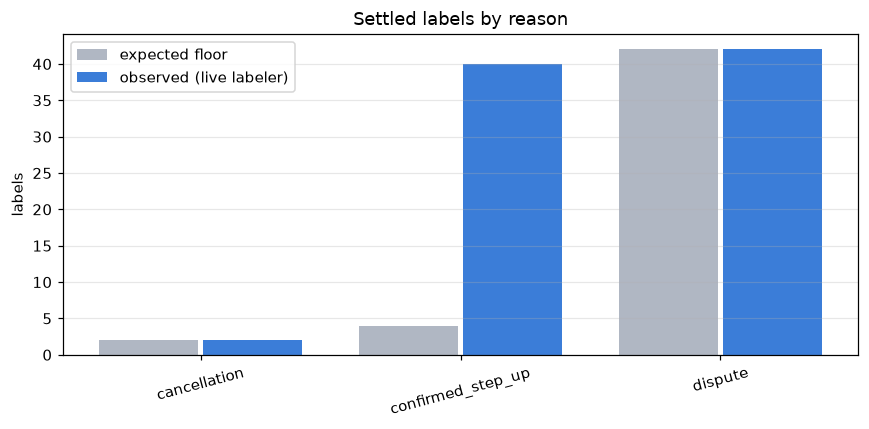

In [5]:
lb = ev.label_breakdown(results)
lab = pd.DataFrame(lb["by_reason"])
display(lab)
print("observed by value:", lb["by_value"], " | total labels:", lb["observed_count"])

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(lab))
ax.bar(x - 0.2, lab["expected"], width=0.38, label="expected floor", color="#b0b7c3")
ax.bar(x + 0.2, lab["observed"], width=0.38, label="observed (live labeler)", color="#3b7dd8")
ax.set_xticks(x); ax.set_xticklabels(lab["reason"], rotation=15)
ax.set_ylabel("labels"); ax.set_title("Settled labels by reason")
ax.legend(); ax.grid(axis="x", alpha=0)
fig.tight_layout(); plt.show()

## 5 · Expected loss — money & friction

Ground truth (not the misuse flag) sets the bar: a debit the generator expects to **gate** (STEP_UP or BLOCK) carries at-risk value the system should hold. Some misuse debits — a bust-out's early legs, a replay's first leg — are themselves *expected to ALLOW*, so they are not at-risk. The system **gates** an at-risk debit by returning anything but ALLOW and **leaks** it by allowing it; an allow-expected debit the system gates is **false friction**.

at-risk debits (gate-expected): 47
  gated by the system : 47   (recall 100.0%)
  leaked (allowed)    : 0
at-risk value         : ₹321,000.00
  value gated         : ₹321,000.00  (100.0%)
  value leaked        : ₹0.00
allow-expected debits : 31
  false friction      : 0  (rate 0.0%)


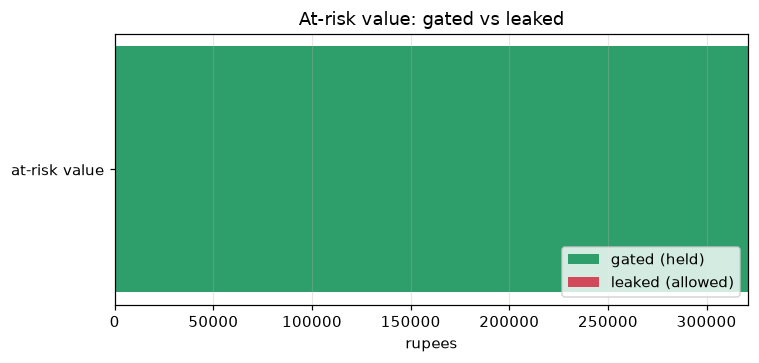

In [6]:
el = ev.expected_loss(results)
print(f"at-risk debits (gate-expected): {el['gate_expected']}")
print(f"  gated by the system : {el['gated']}   (recall {el['recall']:.1%})")
print(f"  leaked (allowed)    : {el['leaked']}")
print(f"at-risk value         : {ev.rupees(el['at_risk_paise'])}")
print(f"  value gated         : {ev.rupees(el['gated_paise'])}  ({el['value_gated_frac']:.1%})")
print(f"  value leaked        : {ev.rupees(el['leaked_paise'])}")
print(f"allow-expected debits : {el['allow_expected']}")
print(f"  false friction      : {el['false_friction']}  (rate {el['false_friction_rate']:.1%})")

fig, ax = plt.subplots(figsize=(7, 3.4))
ax.barh([0], [el["gated_paise"] / 100], color="#2e9e6b", label="gated (held)")
ax.barh([0], [el["leaked_paise"] / 100], left=[el["gated_paise"] / 100], color="#d1495b", label="leaked (allowed)")
ax.set_yticks([0]); ax.set_yticklabels(["at-risk value"])
ax.set_xlabel("rupees"); ax.set_title("At-risk value: gated vs leaked")
ax.legend(loc="lower right"); ax.grid(axis="y", alpha=0)
fig.tight_layout(); plt.show()

## Takeaway

On this run the live system reproduced the generator's ground truth exactly: every family at 100% decision **and** code accuracy, purely diagonal confusion matrices, all at-risk value gated with zero leaked and zero false friction, and the three settled label reasons present for the learning loop.

That is the bar a faithful two-plane replay should clear — the deterministic spine blocks only what a predicate may block, the learned engines raise risk into STEP_UP, and nothing legit is stepped up.

Re-run against your own `results.json` by setting `AGENTSHIELD_RESULTS`, or regenerate one with `python -m agentshield_driver --out results.json`.